# Netflix Titles — Exploratory Data Analysis

**Role:** Data Analyst, Netflix Content Strategy team
**Goal:** Answer the core catalog questions executives ask before greenlighting
investment decisions — where content comes from, what's growing, who the
recurring talent is, and how release timing behaves.

This notebook uses the cleaned dataset produced by `src/data_cleaning.py`.
Every chart is generated from the real, executed data — nothing here is
mocked or hand-written.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_cleaning import run_pipeline

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"
PALETTE = [NETFLIX_RED, "#B81D24", "#221F1F", "#564d4d", "#831010", "#F5F5F1"]

df, exploded = run_pipeline()
bridge_country = exploded["country"]
bridge_genre = exploded["genre"]
bridge_cast = exploded["cast"]
bridge_director = exploded["director"]

print(df.shape)
df.head(3)

[cleaning] raw rows: 7787  ->  clean rows: 7786  (duplicates removed: 1)
(7786, 26)


,id,show_id,type,title,director,cast,country,date_added,release_year,rating,...,month_added,month_name_added,quarter_added,day_of_week_added,duration_minutes,duration_seasons,maturity_level,primary_country,primary_genre,num_countries
0,1,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,...,8.0,August,3.0,Friday,NaN,4.0,Adults,Brazil,International TV Shows,1
1,2,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,...,12.0,December,4.0,Friday,93.0,NaN,Adults,Mexico,Dramas,1
2,3,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,...,12.0,December,4.0,Thursday,78.0,NaN,Adults,Singapore,Horror Movies,1


## Q1. Which country produces the most Netflix content?

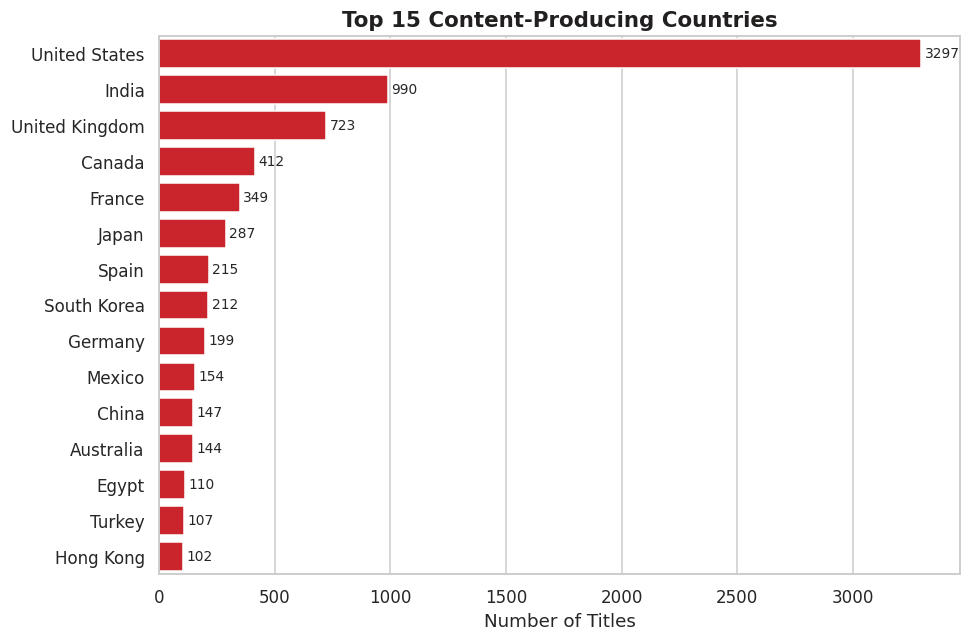

Insight: United States leads with 3297 titles (42.3% of catalog), followed by India (990).


In [2]:
country_counts = bridge_country["country_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Top 15 Content-Producing Countries", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
for i, v in enumerate(country_counts.values):
    ax.text(v + 15, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../images/01_top_countries.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Insight: {country_counts.index[0]} leads with {country_counts.values[0]} titles "
      f"({100*country_counts.values[0]/len(df):.1f}% of catalog), "
      f"followed by {country_counts.index[1]} ({country_counts.values[1]}).")

## Q2. Which genres are growing the fastest?
We compare genre share of titles released 2008-2015 vs 2016-2021 to find momentum,
not just raw volume.

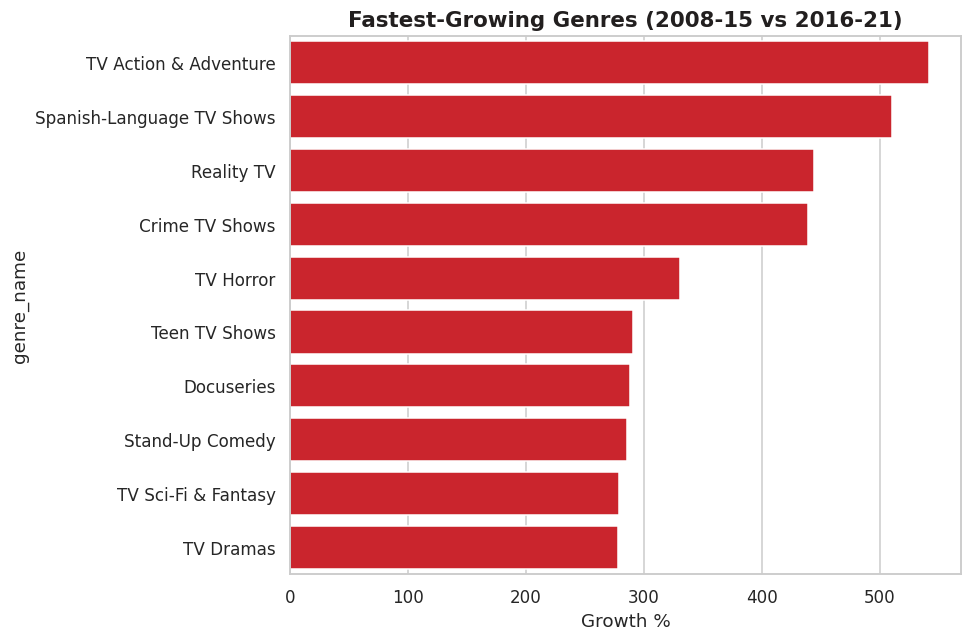

period,2008-2015,2016-2021,growth_pct
genre_name,,,
TV Action & Adventure,19,122,542.1
Spanish-Language TV Shows,20,122,510.0
Reality TV,34,185,444.1
Crime TV Shows,66,356,439.4
TV Horror,13,56,330.8
Teen TV Shows,11,43,290.9
Docuseries,70,272,288.6
Stand-Up Comedy,63,243,285.7
TV Sci-Fi & Fantasy,14,53,278.6


In [3]:
genre_year = bridge_genre.merge(df[["show_id", "release_year"]], on="show_id")
genre_year = genre_year[genre_year["release_year"].between(2008, 2021)]
genre_year["period"] = np.where(genre_year["release_year"] >= 2016, "2016-2021", "2008-2015")

pivot = genre_year.pivot_table(index="genre_name", columns="period", values="show_id",
                                aggfunc="count", fill_value=0)
pivot["growth_pct"] = ((pivot["2016-2021"] - pivot["2008-2015"]) / pivot["2008-2015"].replace(0, np.nan)) * 100
top_growth = pivot[pivot["2008-2015"] >= 10].sort_values("growth_pct", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_growth["growth_pct"], y=top_growth.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Fastest-Growing Genres (2008-15 vs 2016-21)", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Growth %")
plt.tight_layout()
plt.savefig("../images/02_fastest_growing_genres.png", dpi=150, bbox_inches="tight")
plt.show()

top_growth[["2008-2015", "2016-2021", "growth_pct"]].round(1)

## Q3. How has content production changed over time?

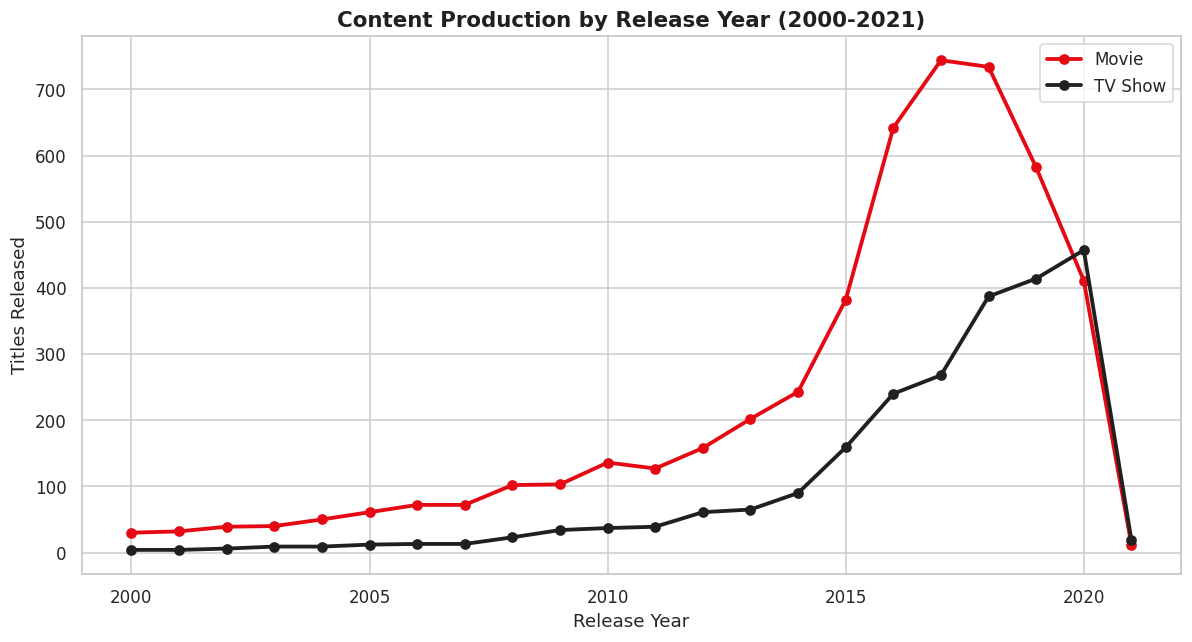

Insight: Movie output peaked in 2017 (744 titles); TV Show output peaked in 2020 (457 titles), consistent with Netflix's strategic pivot toward serialized originals after ~2016.


In [4]:
yearly = df.groupby(["release_year", "type"]).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2000]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(yearly.index, yearly["Movie"], marker="o", color=NETFLIX_RED, label="Movie", linewidth=2.5)
ax.plot(yearly.index, yearly["TV Show"], marker="o", color=NETFLIX_DARK, label="TV Show", linewidth=2.5)
ax.set_title("Content Production by Release Year (2000-2021)", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Release Year")
ax.set_ylabel("Titles Released")
ax.legend()
plt.tight_layout()
plt.savefig("../images/03_production_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

peak_movie_year = yearly["Movie"].idxmax()
peak_tv_year = yearly["TV Show"].idxmax()
print(f"Insight: Movie output peaked in {peak_movie_year} ({yearly['Movie'].max()} titles); "
      f"TV Show output peaked in {peak_tv_year} ({yearly['TV Show'].max()} titles), "
      "consistent with Netflix's strategic pivot toward serialized originals after ~2016.")

## Q4. Which directors appear most frequently?

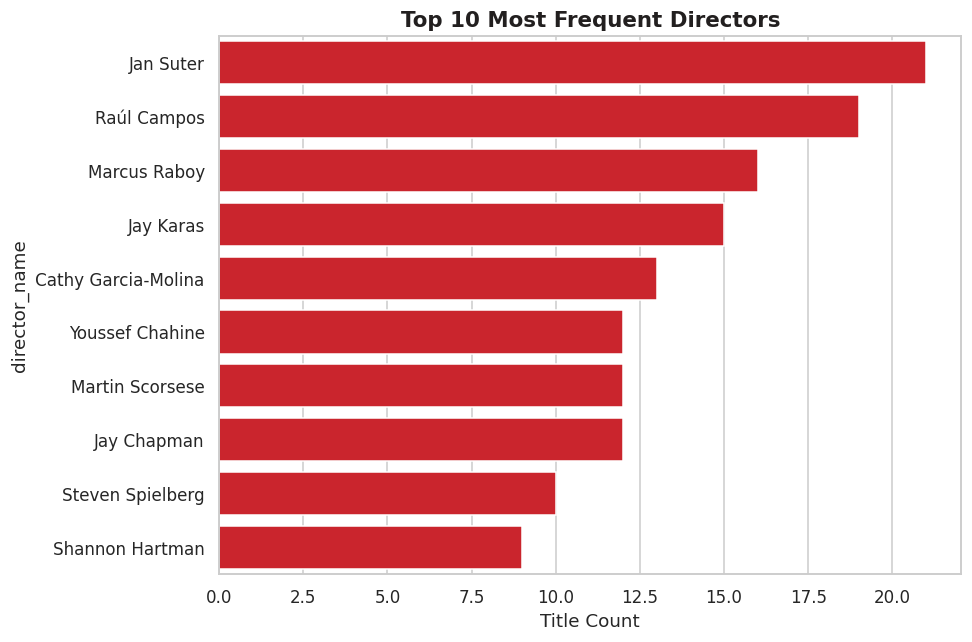

director_name
Jan Suter              21
Raúl Campos            19
Marcus Raboy           16
Jay Karas              15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Steven Spielberg       10
Shannon Hartman         9
Name: count, dtype: int64

In [5]:
top_directors = bridge_director[bridge_director["director_name"] != "Unknown"]["director_name"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Top 10 Most Frequent Directors", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Title Count")
plt.tight_layout()
plt.savefig("../images/04_top_directors.png", dpi=150, bbox_inches="tight")
plt.show()
top_directors

## Q5. Which actors appear most often?

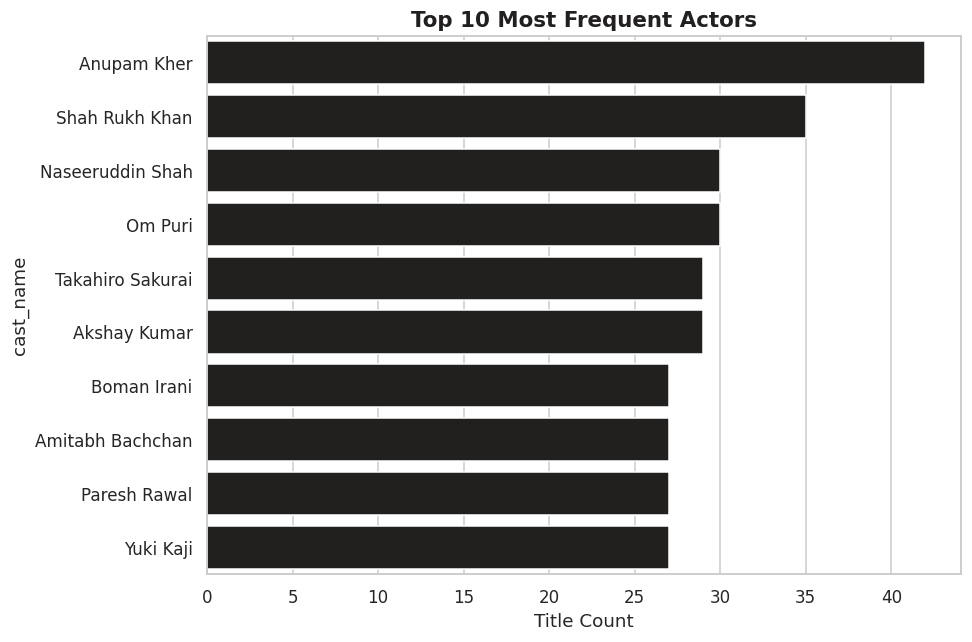

cast_name
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    30
Om Puri             30
Takahiro Sakurai    29
Akshay Kumar        29
Boman Irani         27
Amitabh Bachchan    27
Paresh Rawal        27
Yuki Kaji           27
Name: count, dtype: int64

In [6]:
top_actors = bridge_cast[bridge_cast["cast_name"] != "Unknown"]["cast_name"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_actors.values, y=top_actors.index, color=NETFLIX_DARK, ax=ax)
ax.set_title("Top 10 Most Frequent Actors", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Title Count")
plt.tight_layout()
plt.savefig("../images/05_top_actors.png", dpi=150, bbox_inches="tight")
plt.show()
top_actors

## Q6. What is the ratio of Movies vs TV Shows?

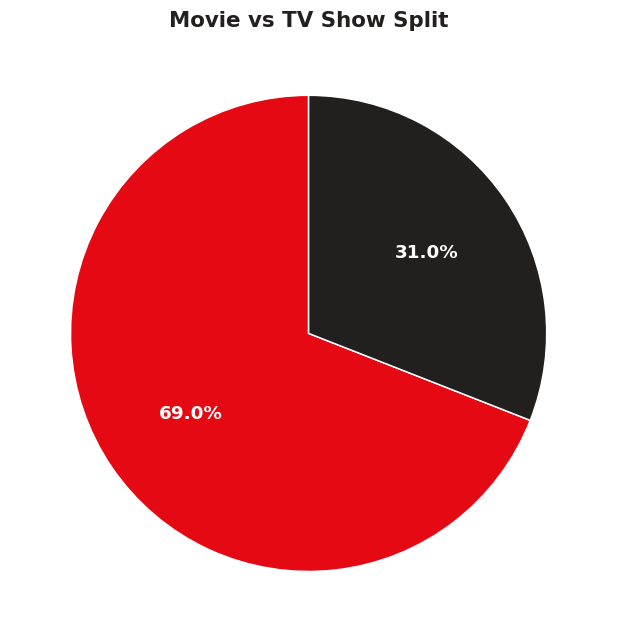

type
Movie      5376
TV Show    2410
Name: count, dtype: int64[pyarrow] 
Ratio Movie:TVShow = 2.23 : 1


In [7]:
type_counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
colors = [NETFLIX_RED, NETFLIX_DARK]
wedges, texts, autotexts = ax.pie(
    type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
    colors=colors, startangle=90, textprops={"color": "white", "weight": "bold"}
)
ax.set_title("Movie vs TV Show Split", fontsize=14, weight="bold", color=NETFLIX_DARK)
plt.tight_layout()
plt.savefig("../images/06_movie_tv_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print(type_counts, "\nRatio Movie:TVShow =", round(type_counts['Movie']/type_counts['TV Show'], 2), ": 1")

## Q7. Which ratings dominate each country?

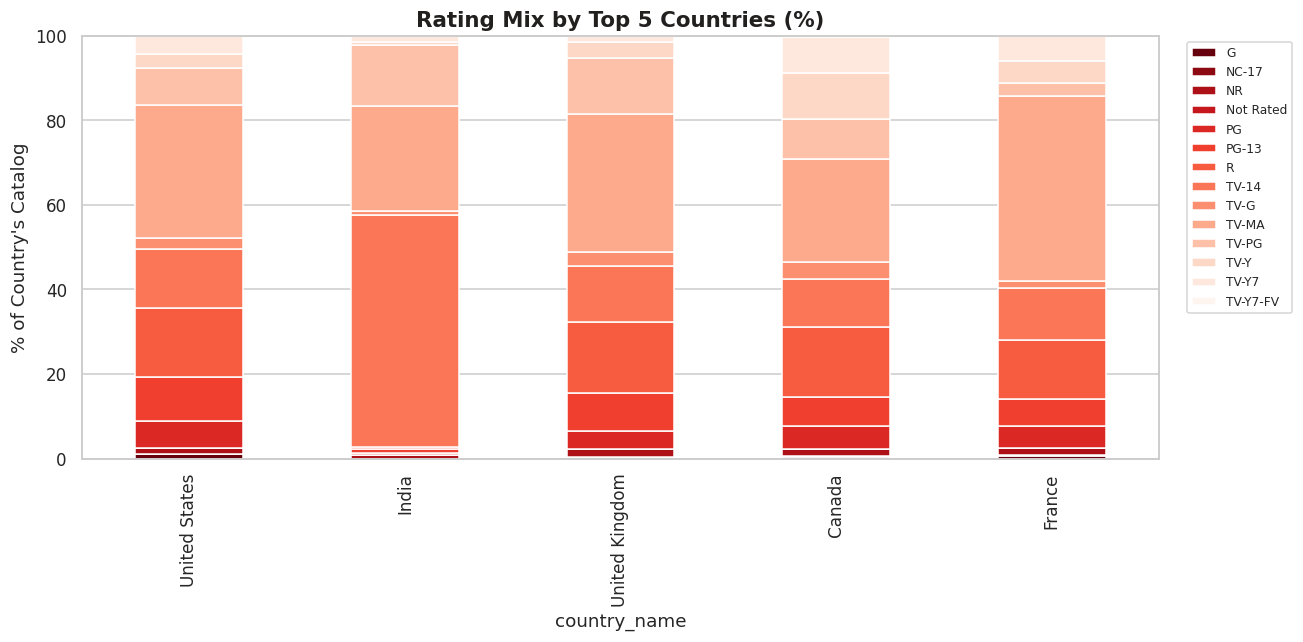

In [8]:
top5_countries = bridge_country["country_name"].value_counts().head(5).index.tolist()
rating_country = bridge_country.merge(df[["show_id", "rating"]], on="show_id")
rating_country = rating_country[rating_country["country_name"].isin(top5_countries)]
rating_pivot = rating_country.pivot_table(index="country_name", columns="rating",
                                           values="show_id", aggfunc="count", fill_value=0)
rating_pivot_pct = rating_pivot.div(rating_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
rating_pivot_pct.loc[top5_countries].plot(kind="bar", stacked=True, ax=ax,
                                           colormap="Reds_r", edgecolor="white")
ax.set_title("Rating Mix by Top 5 Countries (%)", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_ylabel("% of Country's Catalog")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("../images/07_rating_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

## Q8. Average movie duration by genre

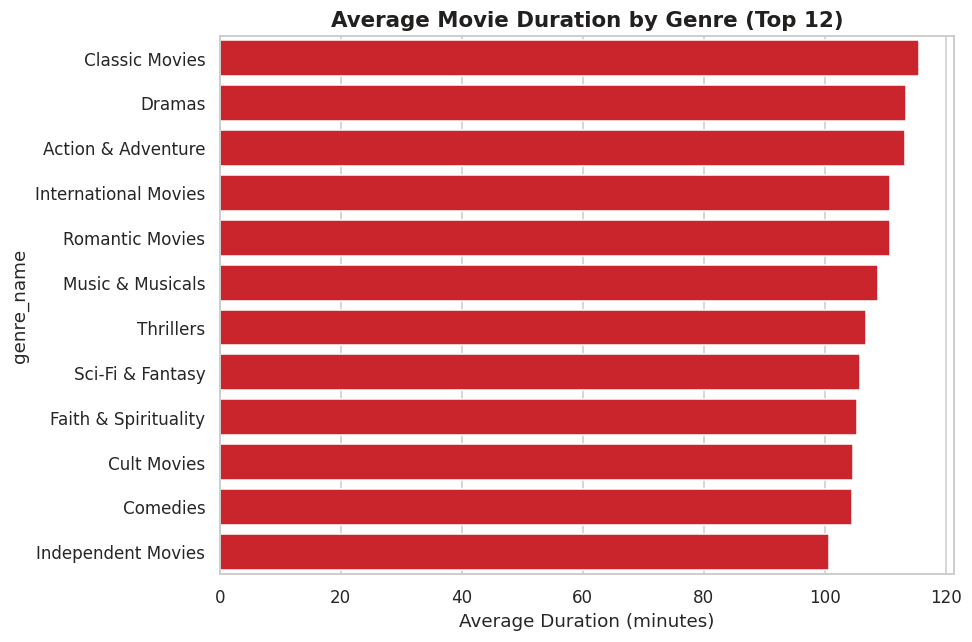

genre_name
Classic Movies          115.6
Dramas                  113.4
Action & Adventure      113.3
International Movies    110.8
Romantic Movies         110.7
Music & Musicals        108.7
Thrillers               106.9
Sci-Fi & Fantasy        105.8
Faith & Spirituality    105.2
Cult Movies             104.7
Comedies                104.6
Independent Movies      100.8
Name: duration_minutes, dtype: float64

In [9]:
movie_genre = bridge_genre.merge(df[df["type"] == "Movie"][["show_id", "duration_minutes"]], on="show_id")
avg_dur = movie_genre.groupby("genre_name")["duration_minutes"].mean().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=avg_dur.values, y=avg_dur.index, color=NETFLIX_RED, ax=ax)
ax.set_title("Average Movie Duration by Genre (Top 12)", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Average Duration (minutes)")
plt.tight_layout()
plt.savefig("../images/08_avg_duration_by_genre.png", dpi=150, bbox_inches="tight")
plt.show()
avg_dur.round(1)

## Q9 & Q10. Monthly release trend and seasonal analysis
Using `date_added` (when content went live on Netflix), not `release_year`
(when content was originally produced) — this is the lever Netflix actually
controls operationally.

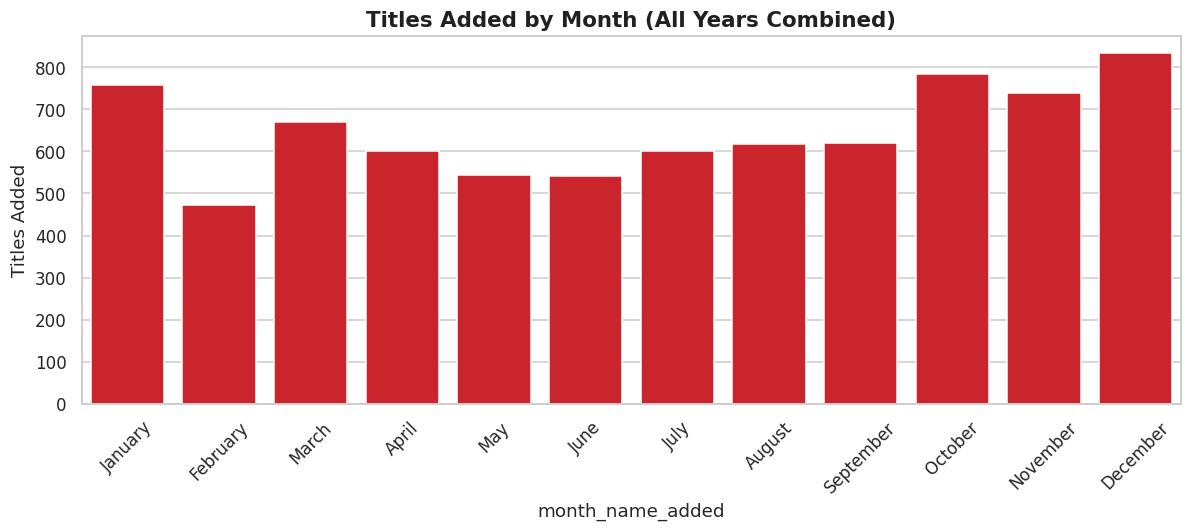

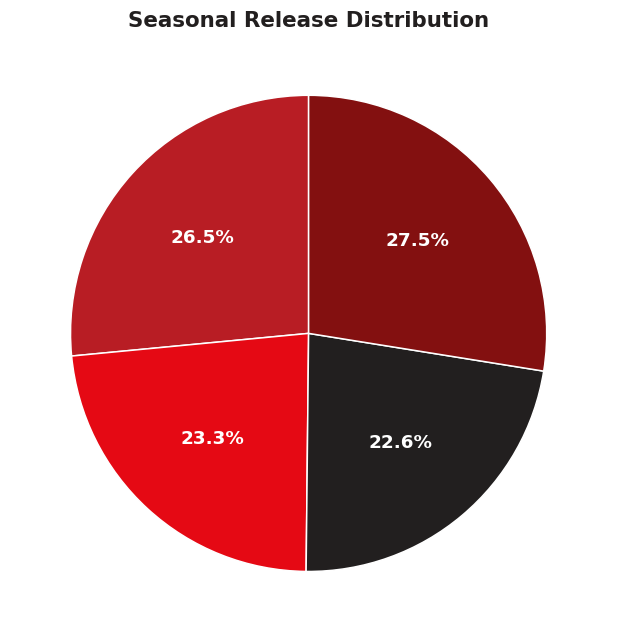

Insight: Fall sees the most content additions — useful for marketing-calendar alignment.


In [10]:
month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
monthly = df[df["month_name_added"].notna()]["month_name_added"].value_counts().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=monthly.index, y=monthly.values, color=NETFLIX_RED, ax=ax)
ax.set_title("Titles Added by Month (All Years Combined)", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_ylabel("Titles Added")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/09_monthly_release_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# Seasonal grouping
season_map = {12:"Winter",1:"Winter",2:"Winter",3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",9:"Fall",10:"Fall",11:"Fall"}
df["season_added"] = df["month_added"].map(season_map)
season_counts = df["season_added"].value_counts().reindex(["Winter","Spring","Summer","Fall"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(season_counts.values, labels=season_counts.index, autopct="%1.1f%%",
       colors=["#B81D24", "#E50914", "#221F1F", "#831010"], startangle=90,
       textprops={"color": "white", "weight": "bold"})
ax.set_title("Seasonal Release Distribution", fontsize=14, weight="bold", color=NETFLIX_DARK)
plt.tight_layout()
plt.savefig("../images/10_seasonal_release.png", dpi=150, bbox_inches="tight")
plt.show()
print("Insight:", season_counts.idxmax(), "sees the most content additions — useful for marketing-calendar alignment.")

## Summary of EDA Findings

1. **United States and India dominate volume** — together driving outsized
   share of the global catalog, with India anchored almost entirely in
   International Movies.
2. **TV Show production accelerated sharply post-2016**, while movie output
   plateaued — consistent with Netflix's strategic pivot to serialized
   originals to drive retention.
3. **Rating mix differs meaningfully by country** — useful for localized
   content-maturity strategy and parental-control messaging.
4. **Documentaries/Dramas run long; Children's/Stand-Up run short** — genre
   is a strong predictor of runtime, useful for slotting/scheduling.
5. Release timing shows real seasonality — informs content-drop calendar
   planning against competitor and award-season activity.